In [ ]:
import pandas as pd
df = pd.read_parquet('/content/markets_10000_20000 (1).parquet') #upload dataset
df.info() # shows the dataset size, number or columns, column details, null values, data types
df.head() #shows the first 5 rows of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   id                    10000 non-null  object             
 1   condition_id          10000 non-null  object             
 2   question              10000 non-null  object             
 3   slug                  10000 non-null  object             
 4   outcomes              10000 non-null  object             
 5   outcome_prices        10000 non-null  object             
 6   clob_token_ids        10000 non-null  object             
 7   volume                10000 non-null  float64            
 8   liquidity             10000 non-null  float64            
 9   active                10000 non-null  bool               
 10  closed                10000 non-null  bool               
 11  end_date              9921 non-null   datetime64[ns, UTC]
 12  creat

,id,condition_id,question,slug,outcomes,outcome_prices,clob_token_ids,volume,liquidity,active,closed,end_date,created_at,market_maker_address,_fetched_at
0,255333,0x0fae1cd8cf19f2e0480edea0fb4b67ea1496baec066c...,Will X remove likes + reposts counter in March?,will-x-remove-likes-reposts-counter-in-march,"[""Yes"", ""No""]","[""0"", ""1""]","[""39050296324364445809641664684679872936491115...",1.140370e+04,0.0,True,True,2024-03-31 00:00:00+00:00,2024-03-07 17:29:32.817000+00:00,0x807477fA08D1544B8750b6C8EB007272A835b28C,2026-02-03 22:24:45.585912
1,255335,0xa0811c97f529d627b7774a5b188e605736b745a1f892...,Fed rate cut by September 18?,fed-rate-cut-by-september-18,"[""Yes"", ""No""]","[""1"", ""0""]","[""50376722767982976792819483321675476184683505...",2.034532e+07,0.0,True,True,2024-09-18 00:00:00+00:00,2024-03-07 18:53:28.276000+00:00,0xFEB5F64B994319d6b6750dD92599Bb7f6822E23b,2026-02-03 22:24:45.585912
2,255336,0x642926331d650ed2e4e1da2593f388cd803b4f283e09...,Fed rate cut by November 7?,fed-rate-cut-by-november-7,"[""Yes"", ""No""]","[""1"", ""0""]","[""93228023618410490101171282292262923995154960...",2.020983e+06,0.0,True,True,2024-11-07 00:00:00+00:00,2024-03-07 18:53:28.351000+00:00,0x196Eca1073D27f82939CAc927E166785CED2439D,2026-02-03 22:24:45.585912
3,255337,0x4057c2528a3815d460f0c5889f52a914745b23400c45...,Fed rate cut by December 18?,fed-rate-cut-by-december-18,"[""Yes"", ""No""]","[""1"", ""0""]","[""11434876408210067129949585931130210316970135...",2.269863e+06,0.0,True,True,2024-12-18 00:00:00+00:00,2024-03-07 18:53:28.352000+00:00,0x2755b28f96fF52f6C1369ba66c11109cd8dBD2ef,2026-02-03 22:24:45.585912
4,255338,0xffe5983ed59a0e850e338d77f0a9a15a2ee72f66f6c7...,Kung Fu Panda 4 over $48m opening weekend?,kung-fu-panda-4-over-48m-opening-weekend,"[""Yes"", ""No""]","[""1"", ""0""]","[""33836461736584363641414201746740864752829976...",4.394703e+04,0.0,True,True,2024-03-11 00:00:00+00:00,2024-03-07 18:57:06.892000+00:00,0x47A21296A97861EAa5346ff90964AE5446dBa0A3,2026-02-03 22:24:45.585912


In [ ]:
# checks for a missing value in each column
df.isnull().sum()

#the relevent columns we need are 'Question' and 'Volume' and their missing values = 0.
#we can ignore 'end_date' and 'created_at' because its not revelent to out question.

,0
id,0
condition_id,0
question,0
slug,0
outcomes,0
outcome_prices,0
clob_token_ids,0
volume,0
liquidity,0
active,0


In [ ]:
# Removes any rows where the question or volume is missing
df = df.dropna(subset=['question', 'volume'])

In [ ]:
# delete any duplicate questions
df = df.drop_duplicates(subset=['question'])

In [ ]:
# checks if everything under 'volume' is actually a number, if anything that is not a number, it turns into a null value
df['volume'] = pd.to_numeric(df['volume'], errors='coerce')

In [ ]:
# Turn messy text into a clean, consistent format for analysis.

import re

def clean_text(q):
    q = q.lower()    # convert all text to lowercase
    q = re.sub(r'[^\w\s]', '', q)    # Remove anything that is not a letter, number, or space
    q = re.sub(r'\s+', ' ', q).strip()   #removes spaces
    return q    # return cleaned text

df['clean_question'] = df['question'].apply(clean_text) #applying the function to the column


In [ ]:
import re

def clean_text(q):
    q = q.lower()
    q = re.sub(r'[^\w\s]', '', q)
    q = re.sub(r'\s+', ' ', q).strip()
    return q

df['clean_question'] = df['question'].apply(clean_text)

## Removes irrelevant words so only meaningful keywords remain for analysis

stopwords = {
    'will','the','in','on','by','of','a','to','is','be',
    'say','during','or','more','and','his','for','at','another'
} # words to ignore/remove

def remove_stopwords(q):
    return ' '.join([w for w in q.split() if w not in stopwords]) #splits words in question, and removes stopwords

df['clean_question'] = df['clean_question'].apply(remove_stopwords)

In [ ]:
from collections import Counter

words = []
for q in df['clean_question']:
    words.extend(q.split())

Counter(words).most_common(50)   #tells us the top 50 most common words within the questions

[('win', 2570),
 ('trump', 1455),
 ('vs', 924),
 ('2024', 887),
 ('beat', 756),
 ('times', 709),
 ('rally', 649),
 ('gold', 607),
 ('october', 522),
 ('election', 510),
 ('points', 509),
 ('kamala', 477),
 ('speech', 392),
 ('between', 360),
 ('us', 301),
 ('end', 277),
 ('womens', 273),
 ('nba', 264),
 ('tweet', 261),
 ('draw', 251),
 ('3', 248),
 ('biden', 247),
 ('mens', 241),
 ('pennsylvania', 231),
 ('harris', 231),
 ('before', 230),
 ('debate', 217),
 ('dnc', 213),
 ('lead', 202),
 ('elon', 194),
 ('town', 190),
 ('next', 189),
 ('than', 186),
 ('donald', 186),
 ('friday', 181),
 ('candidate', 177),
 ('game', 177),
 ('most', 171),
 ('hall', 170),
 ('michigan', 167),
 ('1', 164),
 ('4', 161),
 ('30', 159),
 ('september', 158),
 ('week', 158),
 ('democratic', 157),
 ('republican', 155),
 ('oct', 153),
 ('5', 152),
 ('seats', 150)]

In [ ]:
# Filter the DataFrame to get questions categorized as 'other'
other_questions = df[df['category'] == 'other']['question']

# Print a few sample questions
print("Sample 'other' questions:")
for i, q in enumerate(other_questions.head(10)):
    print(f"- {q}")

Sample 'other' questions:
- Was Moscow attack a false flag?
- Baltimore Bridge ship hacked?
- Will Nic Carter defeat David Hoffman?
- Will David Hoffman defeat Nic Carter?
- Will none of The Squad lose their primaries?
- Will one member of The Squad lose their primary?
- Will two members of The Squad lose their primaries?
- Will three or more members of The Squad lose their primaries?
- Tesla Robotaxi unveiling delayed?
- Will HOBBES reach $1b first?


In [ ]:
# Filter the DataFrame to get questions categorized as 'other'
other_questions = df[df['category'] == 'other']['question']

# Print a few sample questions
print("Sample 'other' questions:")
for i, q in enumerate(other_questions.head(10)):
    print(f"- {q}")

Sample 'other' questions:
- Israel ground offensive in Rafah by March 31?
- Boeing whistleblower foul play determined in March?
- Will Robert F. Kennedy Jr. announce Aaron Rodgers as running mate?
- Will Robert F. Kennedy Jr. announce Jesse Ventura as running mate?
- Will Robert F. Kennedy Jr. announce Andrew Yang as running mate?
- Will Robert F. Kennedy Jr. announce Rand Paul as running mate?
- Will Robert F. Kennedy Jr. announce Tulsi Gabbard as running mate?
- Will Robert F. Kennedy Jr. announce someone else as running mate?
- Will Robert F. Kennedy Jr. announce Mike Rowe as running mate?
- Will Robert F. Kennedy Jr. announce Tony Robbins as running mate?


In [ ]:
# Filter the DataFrame to get questions categorized as 'other'
other_questions = df[df['category'] == 'other']['question']

# Print a few sample questions
print("Sample 'other' questions:")
for i, q in enumerate(other_questions.head(10)):
    print(f"- {q}")

Sample 'other' questions:
- Boeing whistleblower foul play determined in March?
- Retardio major exchange listing in March?
- Pornhub restores access in Texas by March 31?
- SLERF criminal charges in March?
- March Madness: Sum of Final Four seeds >10.5?
- Eric Adams resigns in March?
- Kate Middleton video fake?
- $SMOLE listed on Binance in March?
- $MOG listed on Binance in March?
- Dan Schneider arrested by April 30?


In [ ]:
print("Random sample of 'other' questions:")
for i, q in enumerate(other_questions.sample(30, random_state=42)):
    print(f"- {q}")

Random sample of 'other' questions:
- Mark Robinson domestic misconduct allegations?
- Bieber Baby: Boy or Girl?
- Will Anthony Richardson be the top Fantasy Quarterback?
- Will another team draft J.J. McCarthy?
- Subway World Series?
- Will Davante Adams be the top Fantasy Wide Receiver?
- 538 favorite when forecast is turned on? 
- Will the Denver Broncos draft a QB in the 1st round of the NFL Draft?
- Will the Knicks resign OG Anunoby? 
- Will Florida be the tipping point state?
- Will Silver call 43 states correctly?
- Will Doug Pederson be the first coach fired?
- Will Shkreli escrow $100m?
- Will Ilya join another company?
- Will Josh Jacobs be the top Fantasy Running Back?
- Ninja biggest loser?
- Will another cat memecoin reach $1b first?
- Will Montana's abortion protection measure pass?
- Roaring Kitty says "short squeeze" in livestream?
- Was Moscow attack a false flag?
- Will 538 call 44 states correctly?
- Will the Director of FBI be fired/resign?
- Will RN receive over 31

In [ ]:
print("Random sample of remaining 'other' questions:")
for i, q in enumerate(other_questions.sample(40, random_state=42)):
    print(f"- {q}")

Random sample of remaining 'other' questions:
- Mark Robinson domestic misconduct allegations?
- Bieber Baby: Boy or Girl?
- Will Anthony Richardson be the top Fantasy Quarterback?
- Will another team draft J.J. McCarthy?
- Subway World Series?
- Will Davante Adams be the top Fantasy Wide Receiver?
- 538 favorite when forecast is turned on? 
- Will the Denver Broncos draft a QB in the 1st round of the NFL Draft?
- Will the Knicks resign OG Anunoby? 
- Will Florida be the tipping point state?
- Will Silver call 43 states correctly?
- Will Doug Pederson be the first coach fired?
- Will Shkreli escrow $100m?
- Will Ilya join another company?
- Will Josh Jacobs be the top Fantasy Running Back?
- Ninja biggest loser?
- Will another cat memecoin reach $1b first?
- Will Montana's abortion protection measure pass?
- Roaring Kitty says "short squeeze" in livestream?
- Was Moscow attack a false flag?
- Will 538 call 44 states correctly?
- Will the Director of FBI be fired/resign?
- Will RN recei

In [ ]:
def categorize(q):
    q = q.lower()

    # Politics
    if any(word in q for word in [
        'trump', 'election', 'kamala', 'speech', 'biden', 'harris', 'debate', 'dnc', 'donald', 'candidate', 'democratic', 'republican', 'pennsylvania', 'michigan', 'russia', 'ukraine', 'war', 'us', 'israel', 'rafah', 'running mate', 'kennedy jr', 'resigns', 'eric adams', 'moscow attack', 'false flag', 'the squad', 'primaries', 'nic carter', 'david hoffman', 'state', 'votes', 'forecast', '538', 'fbi', 'director', 'receive', 'tipping point', 'abortion', 'measure', 'rn', 'td', 'ap', 'called', 'states correctly', '538', 'forecast', 'tipping point', 'state', 'states', 'votes', 'vote', 'ap', 'call', 'election', 'abortion', 'fbi', 'director', 'rn', 'td', 'north carolina', 'arizona', 'moscow', 'false flag'
    ]):
        return 'politics'

    # Sports
    elif any(word in q for word in [
         'win', 'vs', 'beat', 'points', 'draw', 'nba', 'match', 'game', 'score', 'hall', 'womens', 'mens', 'championship', 'cup', 'medal', 'olympics', 'playoffs', 'season', 'lead', 'march madness', 'final four', 'seeds', 'fantasy', 'quarterback', 'wide receiver', 'running back', 'nfl', 'draft', 'broncos', 'knicks', 'coach', 'world series', 'resign', 'top fantasy', 'jacobs', 'anthony richardson', 'cj stroud', 'davante adams', 'jj mccarthy', 'pederson', 'fantasy', 'quarterback', 'wide receiver', 'running back', 'draft', 'broncos', 'knicks', 'coach', 'world series', 'dodgers', 'mets', 'runs', 'qb', 'wr', 'nfl', 'anthony richardson', 'jj mccarthy', 'davante adams', 'cj stroud', 'ceedee lamb', 'josh jacobs', 'pederson'
    ]):
        return 'sports'

    # Economics / Markets
    elif any(word in q for word in [
         'gold', 'market', 'stock', 'fed', 'rate', 'inflation', 'economy', 'gdp', 'price', 'interest', 'bond', 'recession', 'growth', 'earn', 'revenue', 'profit', 'q1', 'q2', 'q3', 'q4'
    ]):
        return 'economics'

    # Crypto
    elif any(word in q for word in [
        'bitcoin', 'ethereum', 'crypto', 'eth', 'sol', '$smole', '$mog', 'binance', 'retardio', 'hobbes', '$1b', 'slerf', 'memecoin', 'escrow', '$100m', 'short squeeze', 'roaring kitty', 'memecoin', 'short squeeze', 'roaring kitty', 'hobbes', '1b', '100m', 'escrow'
    ]):
        return 'crypto'

    # Tech / Social
    elif any(word in q for word in [
        'tweet', 'elon', 'twitter', 'tiktok', 'ai', 'gpt', 'spacex', 'post', 'update', 'feature', 'app', 'software', 'pornhub', 'tesla', 'robotaxi', 'anthropic', 'mira murati', 'ilya', 'company', 'livestream', 'ilya', 'anthropic', 'google', 'x', 'bans', 'mira murati'
    ]):
        return 'tech'

    # Legal
    elif any(word in q for word in [
        'guilty', 'sentence', 'trial', 'court', 'jail', 'prison', 'whistleblower', 'foul play', 'criminal charges', 'arrested', 'boeing whistleblower'
    ]):
        return 'legal'

    # Entertainment
    elif any(word in q for word in [
       'movie', 'film', 'music', 'album', 'box', 'office', 'kate middleton', 'bieber', 'baby', 'boy or girl', 'ninja', 'bieber', 'baby', 'ninja', 'youtube', 'streaming', 'record', 'barney', 'ansem'
    ]):
        return 'entertainment'

    # Events / Time
    elif any(word in q for word in [
        '2024','october','july','may','august','june', 'day', 'week', 'month', 'year', 'morning', 'afternoon', 'evening', 'tonight', 'tomorrow', 'yesterday', 'today', 'date', 'time', 'end', 'start', 'finish', 'before', 'after', 'next', 'past', 'times', 'march', 'april'
    ]):
        return 'events'

    return 'other'

df['category'] = df['clean_question'].apply(categorize) #categorizes each question into a section

counts = df['category'].value_counts() # counts how many times a category comes up
percentages = df['category'].value_counts(normalize=True) * 100   # Calculates category percentages

summary = pd.DataFrame({
    'count': counts,
    'percentage': percentages.round(2)
})

summary ## Combines counts + percentages into one clean summary table.

,count,percentage
category,,
politics,4708,49.11
sports,3633,37.90
tech,442,4.61
events,325,3.39
crypto,195,2.03
other,137,1.43
economics,67,0.70
legal,46,0.48
entertainment,33,0.34


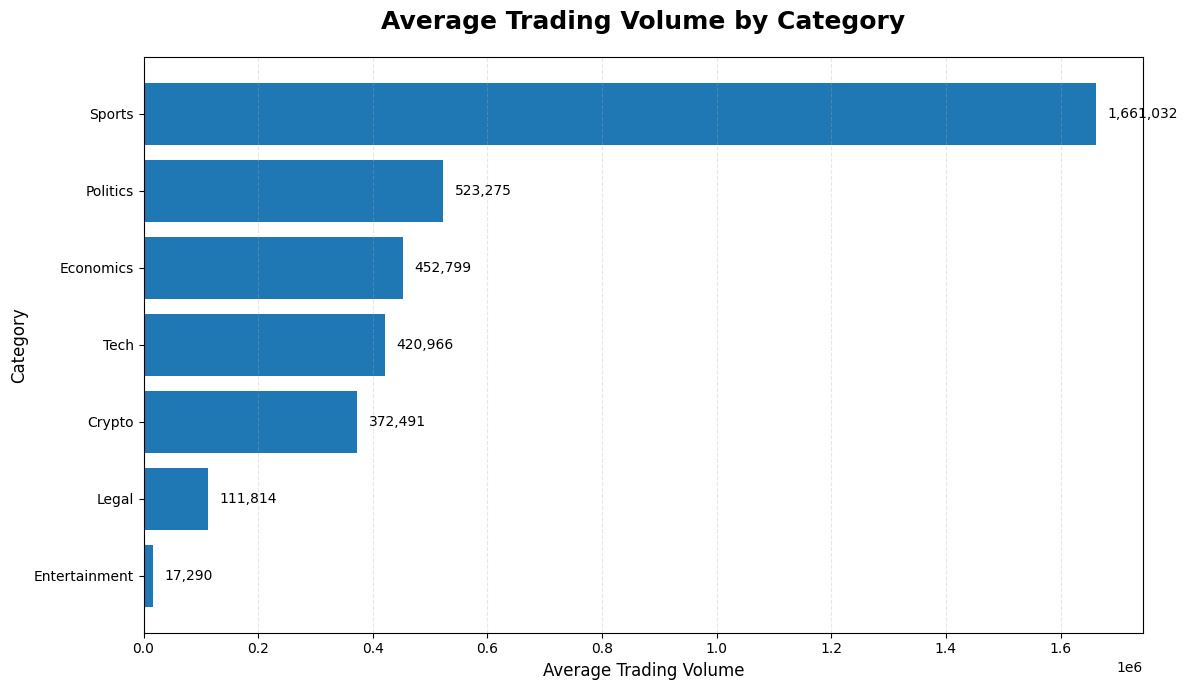

In [ ]:
import matplotlib.pyplot as plt

# Average volume data
categories = [
    'Sports',
    'Politics',
    'Economics',
    'Tech',
    'Crypto',
    'Legal',
    'Entertainment'
]

volumes = [
    1661032,
    523275,
    452799,
    420966,
    372491,
    111814,
    17290
]

# Create figure
plt.figure(figsize=(12,7))

# Horizontal bar chart
bars = plt.barh(categories, volumes)

# Reverse order so highest appears at top
plt.gca().invert_yaxis()

# Title and labels
plt.title(
    'Average Trading Volume by Category',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Average Trading Volume',
    fontsize=12
)

plt.ylabel(
    'Category',
    fontsize=12
)

# Add grid
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 20000,
        bar.get_y() + bar.get_height()/2,
        f'{width:,.0f}',
        va='center'
    )

plt.tight_layout()
plt.show()

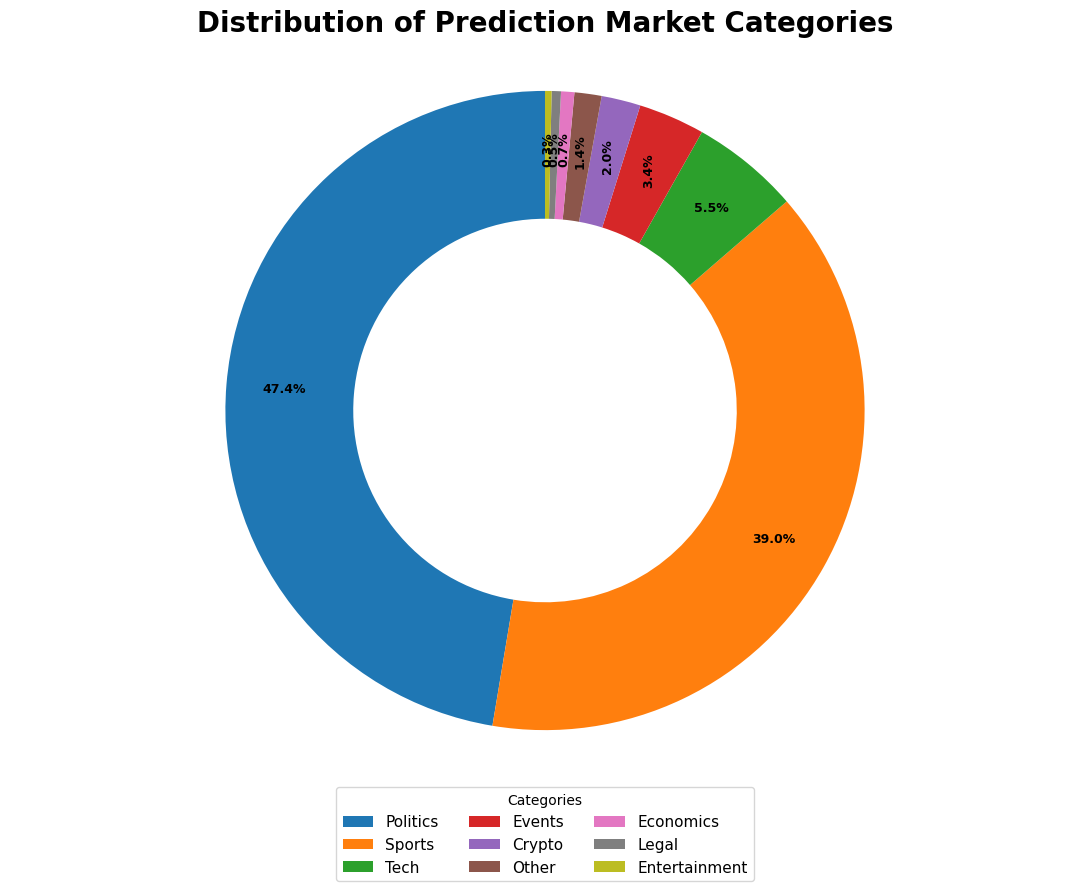

In [ ]:
import matplotlib.pyplot as plt

# Data
categories = [
    'Politics',
    'Sports',
    'Tech',
    'Events',
    'Crypto',
    'Other',
    'Economics',
    'Legal',
    'Entertainment'
]

percentages = [
    47.37,
    38.98,
    5.48,
    3.35,
    1.98,
    1.37,
    0.67,
    0.47,
    0.33
]

# Create figure
fig, ax = plt.subplots(figsize=(11,9))

# Create donut chart
wedges, texts, autotexts = ax.pie(
    percentages,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.4)
)

# Rotate labels conditionally
for i, autotext in enumerate(autotexts):

    # Keep big categories horizontal
    if categories[i] in ['Politics', 'Sports', 'Tech']:
        autotext.set_rotation(0)

    # Rotate smaller categories vertically
    else:
        autotext.set_rotation(90)

    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

# Title
plt.title(
    'Distribution of Prediction Market Categories',
    fontsize=20,
    fontweight='bold',
    pad=20
)

# Legend
plt.legend(
    wedges,
    categories,
    title="Categories",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    fontsize=11
)

# Keep circle shape
ax.axis('equal')

plt.tight_layout()
plt.show()